# Multi-model benchmark results

Load Oolong Real and BrowseComp-Plus `multi_model_benchmarks/**/results*.jsonl` into one pandas `DataFrame`.

- One row per trial (no aggregation).
- Skips `latest.jsonl` (symlink).
- **Write-back:** after editing the table (e.g. `success`), call `write_multi_model_benchmark_results(df)` to overwrite each `source_file` using **only** the canonical JSONL columns (no `benchmark` / `source_file` on disk). If you edit JSONL by hand, use **JSON** syntax: `true` / `false` / `null` (not Python `True` / `False` / `None`).
- Requires **pandas**: `uv pip install pandas`

**Run this notebook with the working directory set to the `rlm` repository root** (or set `REPO_ROOT` in the next cell).

In [3]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "bench_Oolong_real").is_dir():
    raise RuntimeError(
        "Set the notebook working directory to the rlm repo root, or assign REPO_ROOT manually."
    )

In [8]:
import json


def _jsonl_paths_for_benchmark(
    multi_root: Path,
    *,
    include_stable: bool,
    include_timestamped: bool,
) -> list[Path]:
    if not multi_root.is_dir():
        return []
    out: list[Path] = []
    for baseline_dir in sorted(p for p in multi_root.iterdir() if p.is_dir()):
        if include_stable:
            stable = baseline_dir / "results.jsonl"
            if stable.is_file():
                out.append(stable)
        if include_timestamped:
            out.extend(sorted(baseline_dir.glob("results_*.jsonl")))
    return out


def discover_result_paths(
    *,
    repo_root: Path | None = None,
    include_stable: bool = True,
    include_timestamped: bool = False,
) -> list[tuple[str, Path]]:
    root = repo_root or REPO_ROOT
    oolong = root / "bench_Oolong_real" / "multi_model_benchmarks"
    browse = root / "bench_BrowseComp-Plus" / "multi_model_benchmarks"
    pairs: list[tuple[str, Path]] = []
    for label, multi in (
        ("oolong_real", oolong),
        ("browsecomp_plus", browse),
    ):
        for p in _jsonl_paths_for_benchmark(
            multi,
            include_stable=include_stable,
            include_timestamped=include_timestamped,
        ):
            pairs.append((label, p))
    return pairs


def _load_one_jsonl(benchmark: str, path: Path) -> pd.DataFrame:
    rows: list[dict] = []
    text = path.read_text(encoding="utf-8")
    for lineno, line in enumerate(text.splitlines(), start=1):
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError as e:
            raise ValueError(
                f"Invalid JSON in {path} line {lineno}: {e.msg}\n"
                f"Use JSON booleans true/false and null (not Python True/False/None)."
            ) from e
    df = pd.DataFrame(rows)
    df.insert(0, "benchmark", benchmark)
    df["source_file"] = str(path)
    return df


def load_multi_model_benchmark_results(
    *,
    repo_root: Path | None = None,
    include_stable: bool = True,
    include_timestamped: bool = False,
) -> pd.DataFrame:
    pairs = discover_result_paths(
        repo_root=repo_root,
        include_stable=include_stable,
        include_timestamped=include_timestamped,
    )
    if not pairs:
        return pd.DataFrame()
    frames = [_load_one_jsonl(b, p) for b, p in pairs]
    return pd.concat(frames, ignore_index=True)

In [7]:
df = load_multi_model_benchmark_results()

In [9]:
def classify_prompt(source_file: str) -> str:
    if "confidence_selfeval_" in source_file:
        return "confidence_selfeval"
    if "dynamic_selection_" in source_file:
        return "dynamic_selection"
    return "normal"

df["prompt_type"] = df["source_file"].apply(classify_prompt)

df_confidence_selfeval = df[df["prompt_type"] == "confidence_selfeval"].copy()
df_dynamic_selection   = df[df["prompt_type"] == "dynamic_selection"].copy()
df_normal              = df[df["prompt_type"] == "normal"].copy()

print(f"normal:               {len(df_normal)} rows")
print(f"confidence_selfeval:  {len(df_confidence_selfeval)} rows")
print(f"dynamic_selection:    {len(df_dynamic_selection)} rows")

normal:               60 rows
confidence_selfeval:  60 rows
dynamic_selection:    40 rows


In [10]:
print(f"rows={len(df)}  columns={list(df.columns)}")
# display(df)

rows=160  columns=['benchmark', 'task_id', 'query', 'baseline', 'trial', 'ground_truth', 'response', 'success', 'subagent_calls_mini', 'subagent_calls_nano', 'total_time', 'input_tokens', 'source_file', 'prompt_type']


In [17]:
def _get_agg_spec(dataframe):
    """
    Returns a valid pandas aggregation spec mapping.
    Avoids passing None or empty keys to .agg()
    """
    spec = {
        "num_tasks": ("task_id", "nunique"),
    }
    if "score" in dataframe.columns:
        spec["mean_score"] = ("score", "mean")
    if "success" in dataframe.columns:
        spec["success_rate"] = ("success", "mean")
    if "total_time" in dataframe.columns:
        spec["avg_time_sec"] = ("total_time", "mean")
    if "input_tokens" in dataframe.columns:
        spec["avg_input_tokens"] = ("input_tokens", "mean")

    return spec


# 1. Determine which grouping columns are available
group_cols = []
if "prompt_type" in df.columns:
    group_cols.append("prompt_type")
if "benchmark" in df.columns:
    group_cols.append("benchmark")
if "baseline" in df.columns:
    group_cols.append("baseline")

# 2. Perform the combined aggregation
if group_cols:
    # We use a list [group_cols] to group by multiple levels simultaneously
    combined_agg = df.groupby(group_cols).agg(**_get_agg_spec(df)).round(2)

    print(f"Aggregate by {(' and ').join(group_cols)}:")
    display(combined_agg)

    # Optional: If you want to see the table flattened (no multi-index)
    # display(combined_agg.reset_index())
else:
    print("Neither 'benchmark' nor 'baseline' columns found in the DataFrame.")

Aggregate by prompt_type and benchmark and baseline:


num_tasks  \
prompt_type         benchmark       baseline                                     
confidence_selfeval browsecomp_plus flagship-root_nano-sub                   5   
                                    mini-root_mini-sub                       5   
                                    mini-root_nano-sub                       5   
                    oolong_real     flagship-root_nano-sub                   5   
                                    mini-root_mini-sub                       5   
                                    mini-root_nano-sub                       5   
dynamic_selection   browsecomp_plus dynamic_selection_flagship_root          5   
                                    dynamic_selection_mini_root              5   
                    oolong_real     dynamic_selection_flagship_root          5   
                                    dynamic_selection_mini_root              5   
normal              browsecomp_plus flagship-root_nano-sub                   5   
                                    mini-root_mini-sub                       5   
                                    mini-root_nano-sub                       5   
                    oolong_real     flagship-root_nano-sub                   5   
                                    mini-root_mini-sub                       5   
                                    mini-root_nano-sub                       5   

                                                                     success_rate  \
prompt_type         benchmark       baseline                                        
confidence_selfeval browsecomp_plus flagship-root_nano-sub                    0.8   
                                    mini-root_mini-sub                        0.7   
                                    mini-root_nano-sub                        1.0   
                    oolong_real     flagship-root_nano-sub                    0.2   
                                    mini-root_mini-sub                        0.2   
                                    mini-root_nano-sub                        0.2   
dynamic_selection   browsecomp_plus dynamic_selection_flagship_root           0.9   
                                    dynamic_selection_mini_root               0.6   
                    oolong_real     dynamic_selection_flagship_root           0.4   
                                    dynamic_selection_mini_root               0.1   
normal              browsecomp_plus flagship-root_nano-sub                    0.8   
                                    mini-root_mini-sub                        0.8   
                                    mini-root_nano-sub                        0.6   
                    oolong_real     flagship-root_nano-sub                    0.4   
                                    mini-root_mini-sub                        0.1   
                                    mini-root_nano-sub                        0.3   

                                                                     avg_time_sec  \
prompt_type         benchmark       baseline                                        
confidence_selfeval browsecomp_plus flagship-root_nano-sub                  73.71   
                                    mini-root_mini-sub                      60.98   
                                    mini-root_nano-sub                      38.12   
                    oolong_real     flagship-root_nano-sub                  80.98   
                                    mini-root_mini-sub                      93.05   
                                    mini-root_nano-sub                      15.64   
dynamic_selection   browsecomp_plus dynamic_selection_flagship_root         71.84   
                                    dynamic_selection_mini_root             77.68   
                    oolong_real     dynamic_selection_flagship_root         73.88   
                                    dynamic_selection_mini_root             24.15   
normal              browsecomp_plus flags

In [15]:
# Aggregated by prompt_type + benchmark only (averaged across all baselines)
print("Aggregate by prompt_type and benchmark (averaged across baselines):")
prompt_agg = (
    df.groupby(["prompt_type", "benchmark"])
    .agg(**_get_agg_spec(df))
    .round(2)
)
display(prompt_agg)

Aggregate by prompt_type and benchmark (averaged across baselines):


num_trials  num_tasks  success_rate  \
prompt_type         benchmark                                              
confidence_selfeval browsecomp_plus           2          5          0.83   
                    oolong_real               2          5          0.20   
dynamic_selection   browsecomp_plus           2          5          0.75   
                    oolong_real               2          5          0.25   
normal              browsecomp_plus           2          5          0.73   
                    oolong_real               2          5          0.27   

                                     avg_time_sec  avg_input_tokens  
prompt_type         benchmark                                        
confidence_selfeval browsecomp_plus         57.60         175954.33  
                    oolong_real             63.22          91283.10  
dynamic_selection   browsecomp_plus         74.76         251729.60  
                    oolong_real             49.01          58288.80  
normal              browsecomp_plus         59.60         212260.43  
                    oolong_real             40.93          54880.23

In [18]:
# Trial-separated aggregation: do not pool trial 1 and trial 2 into the same success_rate / time stats
trial_sep_cols = [c for c in ("prompt_type", "benchmark", "baseline", "trial") if c in df.columns]
if trial_sep_cols:
    trial_separated_agg = df.groupby(trial_sep_cols).agg(**_get_agg_spec(df)).round(2)
    print(
        f"Aggregate by {' and '.join(trial_sep_cols)} "
        "(each trial index kept separate; not merged across trials):"
    )
    display(trial_separated_agg)

# Coarser view: same, but average across baselines while still separating trials
trial_sep_pb = [c for c in ("prompt_type", "benchmark", "trial") if c in df.columns]
if len(trial_sep_pb) == 3:
    trial_sep_prompt_bench = df.groupby(trial_sep_pb).agg(**_get_agg_spec(df)).round(2)
    print(
        "\nBy prompt_type and benchmark and trial "
        "(trials separate; metrics averaged across baselines only):"
    )
    display(trial_sep_prompt_bench)

Aggregate by prompt_type and benchmark and baseline and trial (each trial index kept separate; not merged across trials):


num_tasks  \
prompt_type         benchmark       baseline                        trial              
confidence_selfeval browsecomp_plus flagship-root_nano-sub          1              5   
                                                                    2              5   
                                    mini-root_mini-sub              1              5   
                                                                    2              5   
                                    mini-root_nano-sub              1              5   
                                                                    2              5   
                    oolong_real     flagship-root_nano-sub          1              5   
                                                                    2              5   
                                    mini-root_mini-sub              1              5   
                                                                    2              5   
                                    mini-root_nano-sub              1              5   
                                                                    2              5   
dynamic_selection   browsecomp_plus dynamic_selection_flagship_root 1              5   
                                                                    2              5   
                                    dynamic_selection_mini_root     1              5   
                                                                    2              5   
                    oolong_real     dynamic_selection_flagship_root 1              5   
                                                                    2              5   
                                    dynamic_selection_mini_root     1              5   
                                                                    2              5   
normal              browsecomp_plus flagship-root_nano-sub          1              5   
                                                                    2              5   
                                    mini-root_mini-sub              1              5   
                                                                    2              5   
                                    mini-root_nano-sub              1              5   
                                                                    2              5   
                    oolong_real     flagship-root_nano-sub          1              5   
                                                                    2              5   
                                    mini-root_mini-sub              1              5   
                                                                    2              5   
                                    mini-root_nano-sub              1              5   
                                                                    2              5   

                                                                           success_rate  \
prompt_type         benchmark       baseline                        trial                 
confidence_selfeval browsecomp_plus flagship-root_nano-sub          1               0.8   
                                                                    2               0.8   
                                    mini-root_mini-sub              1               0.8   
                                                                    2               0.6   
                                    mini-root_nano-sub              1               1.0   
                                                                    2               1.0   
                    oolong_real     flagship-root_nano-sub          1               0.2   
                                                                    2               0.2   
                                    mini-root_mini-sub              1               0.2   
                                                                    2            


By prompt_type and benchmark and trial (trials separate; metrics averaged across baselines only):


num_tasks  success_rate  \
prompt_type         benchmark       trial                            
confidence_selfeval browsecomp_plus 1              5          0.87   
                                    2              5          0.80   
                    oolong_real     1              5          0.20   
                                    2              5          0.20   
dynamic_selection   browsecomp_plus 1              5          0.80   
                                    2              5          0.70   
                    oolong_real     1              5          0.20   
                                    2              5          0.30   
normal              browsecomp_plus 1              5          0.73   
                                    2              5          0.73   
                    oolong_real     1              5          0.33   
                                    2              5          0.20   

                                           avg_time_sec  avg_input_tokens  
prompt_type         benchmark       trial                                  
confidence_selfeval browsecomp_plus 1             55.44         145029.40  
                                    2             59.77         206879.27  
                    oolong_real     1             85.33         122451.20  
                                    2             41.12          60115.00  
dynamic_selection   browsecomp_plus 1             72.17         218370.10  
                                    2             77.36         285089.10  
                    oolong_real     1             46.73          40945.30  
                                    2             51.30          75632.30  
normal              browsecomp_plus 1             56.80         176540.13  
                                    2             62.40         247980.73  
                    oolong_real     1             37.00          50205.53  
                                    2             44.86          59554.93

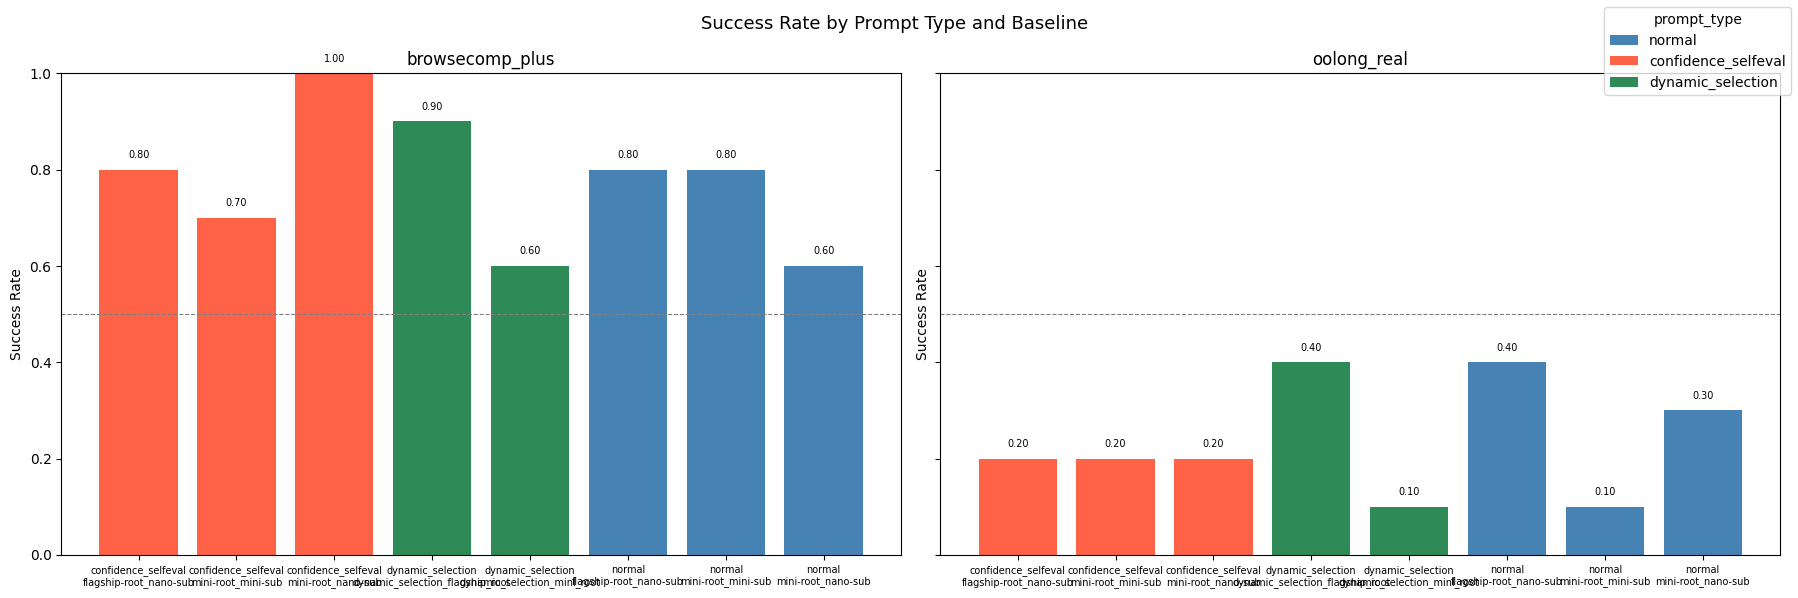

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Build one label per run: "prompt_type / baseline"
agg = (
    df.groupby(["benchmark", "prompt_type", "baseline"])
    .agg(success_rate=("success", "mean"))
    .reset_index()
)
agg["label"] = agg["prompt_type"] + "\n" + agg["baseline"]

# Distinct fill color per baseline (same baseline name = same color across panels)
from matplotlib import cm as _cm

all_baselines = sorted(agg["baseline"].unique())
_n = max(len(all_baselines), 1)
_baseline_cmap = _cm.get_cmap("tab20", _n)
baseline_colors = {b: _baseline_cmap(i) for i, b in enumerate(all_baselines)}

# Hatch pattern differentiates prompt_type on top of baseline color
hatch_by_prompt = {
    "normal": "",
    "confidence_selfeval": "///",
    "dynamic_selection": "xxx",
}
edge_by_prompt = {
    "normal": "#1a237e",
    "confidence_selfeval": "#b71c1c",
    "dynamic_selection": "#1b5e20",
}

benchmarks = sorted(agg["benchmark"].unique())
fig, axes = plt.subplots(1, len(benchmarks), figsize=(18, 6), sharey=True)
if len(benchmarks) == 1:
    axes = [axes]

for ax, bench in zip(axes, benchmarks):
    sub = agg[agg["benchmark"] == bench].sort_values(["prompt_type", "baseline"])
    x = range(len(sub))
    colors = [baseline_colors[b] for b in sub["baseline"]]
    hatches = [hatch_by_prompt.get(pt, "") for pt in sub["prompt_type"]]
    edges = [edge_by_prompt.get(pt, "black") for pt in sub["prompt_type"]]
    bars = ax.bar(
        x,
        sub["success_rate"],
        color=colors,
        edgecolor=edges,
        linewidth=1.8,
    )
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"], rotation=30, ha="right", fontsize=7)
    ax.set_title(bench, fontsize=12)
    ax.set_ylabel("Success Rate")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
    for bar, val in zip(bars, sub["success_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

# Legend: baselines (fill) + prompt_type (hatch + edge)
baseline_patches = [
    Patch(facecolor=baseline_colors[b], edgecolor="grey", label=b[:28] + ("…" if len(b) > 28 else ""))
    for b in all_baselines
]
prompt_patches = [
    Patch(
        facecolor="lightgrey",
        edgecolor=edge_by_prompt[pt],
        hatch=hatch_by_prompt.get(pt, ""),
        linewidth=1.5,
        label=pt,
    )
    for pt in ("normal", "confidence_selfeval", "dynamic_selection")
    if pt in agg["prompt_type"].values
]
fig.legend(
    handles=baseline_patches + prompt_patches,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    fontsize=8,
    title="baseline (fill) / prompt (hatch)",
)

plt.suptitle("Success Rate by Prompt Type and Baseline", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()